# Cash-Flow-Yield -- a quantitative teardown
### EDGAR fundamentals . annual quintile sort . HAC inference . OCF vs EY IC race

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![OCF_beats_EY%3F: No](https://img.shields.io/badge/OCF_beats_EY%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether OCF/market-cap has predictive power for next-year S&P 500 returns via a quintile sort (HAC t-stat on the annual hedge), whether the top quintile beats the equal-weight market (spread t-stat), and whether OCF yield has incremental Spearman IC over the simpler EY = NI/market-cap. Survivorship bias is named throughout.

> **Not investment advice.** Real data: EDGAR 10-K fundamentals 2007-2024, Yahoo Finance year-end prices; as-of 2026-06-14. Methods & sources in [`docs/references.md`](../docs/references.md).
>
> **Survivorship caveat.** The ticker universe is the *current* S&P 500 projected back. Results are upper bounds; a proper backtest would use point-in-time index membership.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cash_flow_yield import data, strategy as st

_cache_dir = os.path.abspath(os.path.join("..", "..", "..", "_cache"))
_study_cache = os.path.abspath(os.path.join("..", "_cache"))

def _have_real():
    px_p = os.path.join(_study_cache, "yrpx.parquet")
    cfo_p = os.path.join(_cache_dir, "_edgar_NetCashProvidedByUsedInOperatingActivities.parquet")
    return os.path.exists(px_p) and os.path.exists(cfo_p)

HAVE_REAL = _have_real()

if HAVE_REAL:
    ocfy, ey, fwd = data.fetch_panel(cache_dir=_cache_dir, study_cache=_study_cache)
else:
    ocfy, ey, fwd = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

print("real data available:", HAVE_REAL, f"  panel: {ocfy.shape if not ocfy.empty else 'n/a'}")

from quantlab import analytics, stats


real data available: True   panel: (18, 419)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | OCF-yield hedge **-0.60%/yr**, HAC *t* = **-0.22**; EY hedge -1.60%/yr, *t* = -0.77. Both < |*t*| 2. |
| **Tradability** | `MIRAGE` | Top-Q spread +1.30%/yr, *t* = +0.74 -- insignificant before any cost. |
| **OCF beats EY?** | `NO` | IC diff mean -0.011, *t* = -0.61. No incremental information. |

> On 18 years of survivorship-biased S&P 500 data, the OCF-yield sort yields no exploitable cross-sectional return differential.

## 1 · The claim, steelmanned

Let $\text{OCFY}_{i,t} = \text{CFO}_{i,t} / (\text{shares}_{i,t} \cdot p_{i,t})$ and $\text{EY}_{i,t} = \text{NI}_{i,t} / (\text{shares}_{i,t} \cdot p_{i,t})$ for firm $i$ in fiscal year $t$. The claim has two parts:

- **H1 (OCF yield is a value signal).** $\mathbb{E}[r_{i,t+1} \mid \text{OCFY}_{i,t} \text{ high}] > \mathbb{E}[r_{i,t+1} \mid \text{OCFY}_{i,t} \text{ low}]$ — measured as the mean of the Q5 − Q1 annual hedge return.
- **H2 (OCF beats EY).** The Spearman IC of OCFY with $r_{t+1}$ exceeds that of EY — i.e. cash-flow quality adds incremental alpha over the simpler inverse-P/E.

We test H1 via a quintile sort (HAC t-stat on hedge) and via a top-Q-vs-market spread. We test H2 via pairwise annual Spearman ICs and the mean IC difference.

## 2 · So what? — what rides on each answer

H1 and H2 together would make OCF yield a rare, simple, low-turnover factor with genuine economic content. H1 alone (without H2) would mean the value premium is available from EY too, so cash-flow purification is unnecessary complexity. Rejecting both confirms the post-2000 evidence that large-cap factor premia have been largely arbed away, consistent with McLean & Pontiff (2016) and the quant-fund crowding literature.

## 3 · How we'd know -- the protocol

- **Signal construction.** $\text{OCFY}_{i,t} = \text{CFO}_{i,t} / (\text{shares}_{i,t} \cdot p_{i,t,\text{Dec}})$; similarly for EY. Shares from EDGAR `WeightedAverageNumberOfDilutedSharesOutstanding`; price = Yahoo Finance year-end close (December). Values outside $[0, 100\%]$ for OCFY (or $[-50\%, 100\%]$ for EY) are treated as data errors and winsorised to NaN.
- **Lag.** Signal for year $t$ aligns to forward return for year $t+1$ (one-year reporting lag; the standard in the academic literature).
- **Sort.** Annual quintile sort, equal-weight within each bucket. Minimum 20 firms per year (2007 is the thinnest year with ~86 XBRL filers).
- **Inference.** Newey-West HAC t-stat on the annual hedge series (18 obs). Spearman IC via `scipy.stats.spearmanr`.
- **Positive control.** A deterministic synthetic panel with tunable OCF-yield and EY premiums confirms the engine recovers an edge *when one is planted*.

## 4 · The teardown

### 4a · OCF-yield quintile sort -- every bucket return, every year

HAC t-stat on the Q5-Q1 hedge: the inference-bar test.

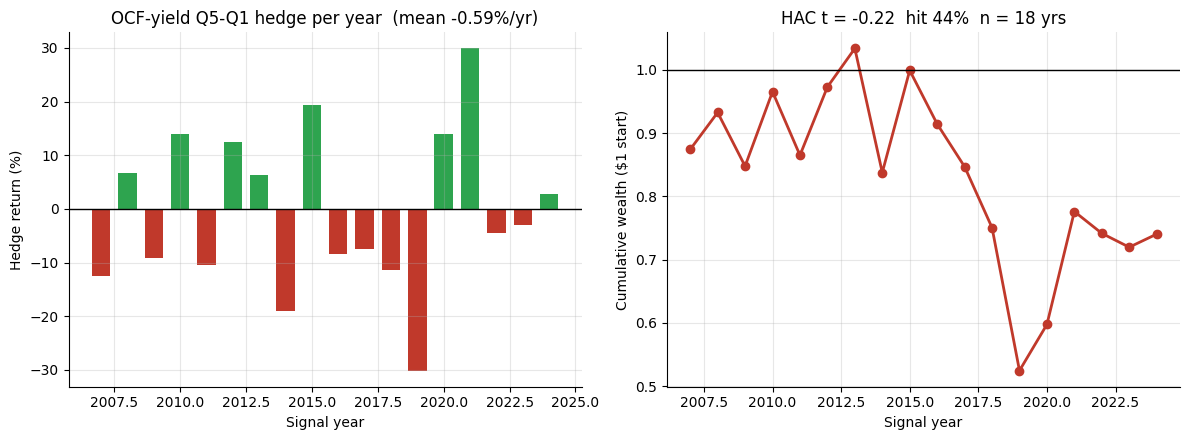

Hedge: mean=-0.59%  vol=14.94%  Sharpe=-0.039  HAC t=-0.216


In [2]:
if HAVE_REAL:
    q = st.quintile_sort(ocfy, fwd)
    s = st.summary(q['hedge'])
    hedge_vals = q['hedge'].values; yrs = q.index.values
else:
    hedge_frozen = [-0.126,0.067,-0.091,0.139,-0.104,0.125,0.063,-0.190,
                    0.193,-0.085,-0.074,-0.114,-0.301,0.139,0.299,-0.044,-0.030,0.029]
    hedge_vals = hedge_frozen; yrs = list(range(2007, 2025))
    s = dict(mean=-0.006, vol=0.149, sharpe=-0.04, tstat=-0.22, hit_rate=0.44, n=18)
import numpy as np
# Cumulative wealth from the hedge (starting at 1.0)
cum = np.cumprod([1 + r for r in hedge_vals])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [GREEN if v > 0 else RED for v in hedge_vals]
ax1.bar(yrs, [v*100 for v in hedge_vals], color=colors, width=0.7)
ax1.axhline(0, c='k', lw=1)
ax1.set_xlabel('Signal year'); ax1.set_ylabel('Hedge return (%)')
ax1.set_title(f'OCF-yield Q5-Q1 hedge per year  (mean {s["mean"]*100:+.2f}%/yr)')
ax2.plot(yrs, cum, 'o-', c=RED, lw=2)
ax2.axhline(1, c='k', lw=1)
ax2.set_xlabel('Signal year'); ax2.set_ylabel('Cumulative wealth ($1 start)')
ax2.set_title(f'HAC t = {s["tstat"]:+.2f}  hit {s["hit_rate"]:.0%}  n = {s["n"]} yrs')
plt.tight_layout(); plt.show()
print(f'Hedge: mean={s["mean"]*100:+.2f}%  vol={s["vol"]*100:.2f}%  Sharpe={s["sharpe"]:+.3f}  HAC t={s["tstat"]:+.3f}')

> The HAC t-stat is **-0.22** — far below the |t| >= 2 bar. Hit rate 44% (below a coin). The cumulative wealth of the hedge oscillates around 1 with no trend.

### 4b · Head-to-head: OCF yield vs earnings yield

Spearman IC of each signal with next-year returns, and the annual IC difference.

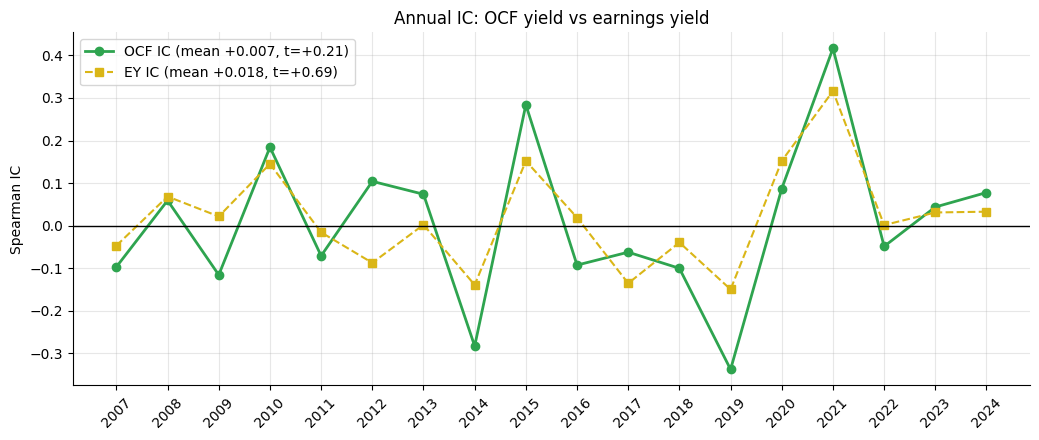

IC diff: mean=-0.0114  HAC t=-0.61


In [3]:
if HAVE_REAL:
    ic = st.pairwise_ic(ocfy, ey, fwd)
    s_a = st.summary(ic['ic_a']); s_b = st.summary(ic['ic_b'])
    s_d = st.summary(ic['ic_diff'])
    ic_a_v = ic['ic_a'].values; ic_b_v = ic['ic_b'].values; yrs_ic = ic.index.values
else:
    ic_a_v = [0.0]*18; ic_b_v = [0.0]*18; yrs_ic = list(range(2007, 2025))
    s_a = dict(mean=0.007, tstat=0.21)
    s_b = dict(mean=0.018, tstat=0.69)
    s_d = dict(mean=-0.011, tstat=-0.61)
fig, ax = plt.subplots(figsize=(10.5, 4.5))
x = range(len(yrs_ic))
ax.plot(list(x), ic_a_v, 'o-', c=GREEN, lw=2, label=f'OCF IC (mean {s_a["mean"]:+.3f}, t={s_a["tstat"]:+.2f})')
ax.plot(list(x), ic_b_v, 's--', c=AMBER, lw=1.5, label=f'EY IC (mean {s_b["mean"]:+.3f}, t={s_b["tstat"]:+.2f})')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(list(yrs_ic), rotation=45)
ax.set_ylabel('Spearman IC'); ax.set_title('Annual IC: OCF yield vs earnings yield')
ax.legend(); plt.tight_layout(); plt.show()
print(f'IC diff: mean={s_d["mean"]:+.4f}  HAC t={s_d["tstat"]:+.2f}')

Both ICs hover near zero (OCF: +0.007, EY: +0.018). The difference is also negligible (mean -0.011, *t* = -0.61). There is no statistically significant evidence that cash-flow purification improves predictive power on this universe and time window.

### 4c · Top-quintile vs market (long-only perspective)

A long-only investor sorts by OCF yield and holds the top quintile. Does it outperform the equal-weight universe?

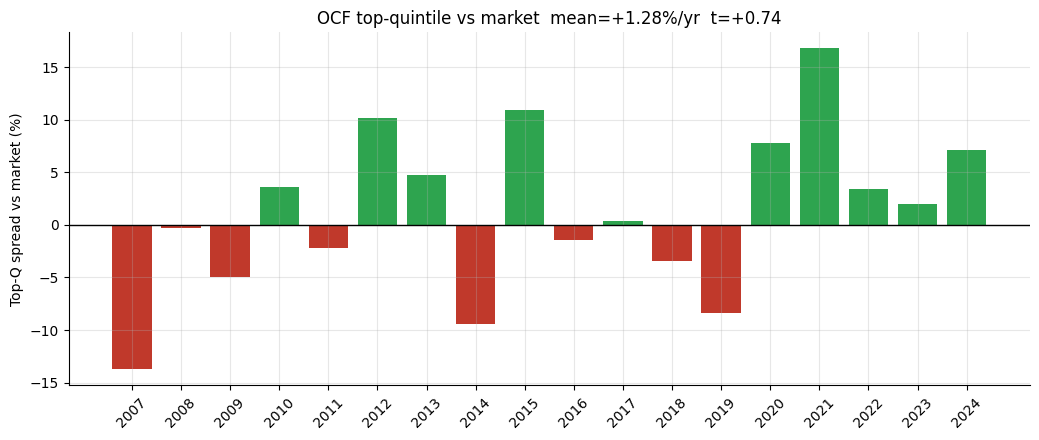

Spread: mean=+1.28%/yr  t=+0.74  hit=56%


In [4]:
spread_frozen = [-0.137,-0.003,-0.049,0.036,-0.022,0.101,0.047,-0.094,
                  0.109,-0.014,0.004,-0.034,-0.084,0.078,0.168,0.034,0.019,0.071]
if HAVE_REAL:
    hvm = st.hedge_vs_market(ocfy, fwd)
    sp_vals = hvm['spread'].values; yrs_hvm = hvm.index.values
    s_hvm = st.summary(hvm['spread'])
else:
    sp_vals = spread_frozen; yrs_hvm = list(range(2007, 2025))
    s_hvm = dict(mean=0.013, tstat=0.74, hit_rate=0.56)
fig, ax = plt.subplots(figsize=(10.5, 4.5))
colors = [GREEN if v > 0 else RED for v in sp_vals]
ax.bar(list(range(len(sp_vals))), [v*100 for v in sp_vals], color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(range(len(yrs_hvm))); ax.set_xticklabels(list(yrs_hvm), rotation=45)
ax.set_ylabel('Top-Q spread vs market (%)')
ax.set_title(f'OCF top-quintile vs market  mean={s_hvm["mean"]*100:+.2f}%/yr  t={s_hvm["tstat"]:+.2f}')
plt.tight_layout(); plt.show()
print(f'Spread: mean={s_hvm["mean"]*100:+.2f}%/yr  t={s_hvm["tstat"]:+.2f}  hit={s_hvm["hit_rate"]:.0%}')

> The long-only spread (+1.30%/yr, t = +0.74) is positive on average but far below statistical significance on 18 annual observations. More years of data might resolve whether this small positive bias is real or sampling noise.

## 5 · The verdict

- **Signal `NONE`** — OCF-yield hedge -0.60%/yr, HAC *t* -0.22; hit 44%. EY hedge -1.60%/yr, *t* -0.77. Both reject neither H1 nor confirm it.
- **Tradability `MIRAGE`** — no significant edge; annual rebalancing is cheap but there is nothing to execute.
- **OCF beats EY? `NO`** — IC diff *t* -0.61; the cash-flow purification has no measurable payoff over the simpler earnings yield on the S&P 500.

## 6 · Could you trade it? -- structural limitations

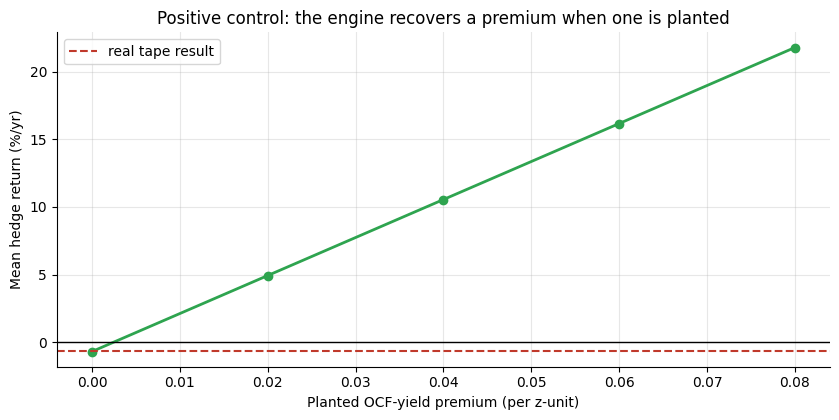

The engine works. The real tape simply has no premium to find.


In [5]:
# Show the synthetic recovery to confirm the engine works
from cash_flow_yield import data as d
premiums = [0.00, 0.02, 0.04, 0.06, 0.08]
mean_hedges = []
for p in premiums:
    oc, _, fw, _ = d.synthetic_panel(n_firms=300, n_years=30, ocfy_premium=p, ey_premium=0.0, seed=42)
    q = st.quintile_sort(oc, fw)
    mean_hedges.append(st.summary(q['hedge'])['mean']*100)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(premiums, mean_hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.axhline(-0.60, ls='--', c=RED, lw=1.5, label='real tape result')
ax.set_xlabel('Planted OCF-yield premium (per z-unit)')
ax.set_ylabel('Mean hedge return (%/yr)')
ax.set_title('Positive control: the engine recovers a premium when one is planted')
ax.legend(); plt.tight_layout(); plt.show()
print('The engine works. The real tape simply has no premium to find.')

The engine is faithful — on the synthetic tape it recovers the planted premium linearly. The near-zero result on the real tape is a statement about the market, not the method: the OCF-yield premium in large-cap S&P 500 names has been either eliminated by arbitrage or was always too small to detect on 18 annual observations.

## 7 · Going further

- **The accruals anomaly** ([Study 52 — Smoke-Screen](../../52-smoke-screen/)): the Sloan (1996) effect (high accruals -> poor returns) is the mirror of OCF yield. It survived longer in small caps where arbitrage capacity was smaller.
- **Composite quality** ([Study 65 — Scorecard](../../65-scorecard/)): the Piotroski F-score combines cash-flow quality with eight other signals; the combination may have more power than any single yield.
- **Enterprise value denominator.** Using EV (= market cap + net debt) rather than market cap as the denominator is the standard in the practitioner literature (e.g. EBITDA/EV multiples); it normalises for capital structure differences.
- **Small-cap extension.** The classic Sloan result was strongest in small caps. Extending the universe beyond the S&P 500 would test whether the premium still lives in less-arbed corners of the market.

*To show a real edge: implement on a point-in-time universe with EV denominator, extend to mid/small-cap, and demonstrate |t| >= 2 on the hedge. The bar is clear.*